In [1]:
from __future__ import annotations
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.base import BaseEstimator
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV


import seaborn as sns
import matplotlib.pyplot as plt

Let's read in the preprocessed data and define some experiment parameters.
- SIMPLE marks whether or not each training set will contain all past time samples or just the current time sample.
- LOG_TRANSFORMED_RUNTIME lets functions know whether to transform the runtime and predictions with an e^x transformation before evaluating the results. 
    - This way, results are always evaluated on the actual runtime predictions rather than the log_runtime predictions

In [2]:
df = pd.read_csv("preprocessed_data/data.csv")
SIMPLE = True
LOG_TRANSFORMED_RUNTIME = "log_runtime" in df.columns

# Function Definitions

In [3]:
def save_plot(title):
    plt.savefig(f"figs/modeling_{title}.png", dpi=300, bbox_inches='tight')

## Error Definitions

In [4]:
def proportional_errors(
        truth:np.ndarray,
        predictions:np.ndarray,
        runtime_log_transformed:bool = LOG_TRANSFORMED_RUNTIME) -> np.ndarray:
    """Proportional error of a model given the predicted runtimes and true runtimes"""
    if runtime_log_transformed:
        truth = np.exp(truth)
        predictions = np.exp(predictions)
    errors = np.abs(truth - predictions) / truth
    return errors

def mean_proportional_error(
        y_true:np.ndarray, y_pred:np.ndarray, 
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME) -> float:
    """mean proportional error of log transformed runtime and """
    if log_transformed_runtime:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) / y_true))

# add mean proportional error to sklearn's scoring system
prop_error_scorer = make_scorer(mean_proportional_error, greater_is_better=False)

## DataFrame Splitting Functions

In [5]:
def drop_other_t_cols(df, curr_t:int, simple:bool=SIMPLE):
    """
    Given the dataframe and current time (0 through 4) drop other time cols from the dataframe.
    Parameters:
        df: the dataframe to drop columns from
        curr_t: current time (0 through 4) for training/testing
        simple: whether or not models are simple (contain fewer cols). 
         - if simple is True: drops every performance col that isn't f"..._t{current_t}"
         - if simple is False: only drops future performance cols (>curr_t)
    returns:
        df: updated dataframe with dropped columns
    """
    drop_cols = []
    for col in df.columns:
        if col[-3:-1] != "_t":
            continue
        col_t = int(col[-1])
        if simple:
            if col_t != curr_t:
                drop_cols.append(col)
        elif col_t > curr_t:
            drop_cols.append(col)
    return df.drop(columns=drop_cols)


def split_df_by_times(
        df:pd.DataFrame,
        simple:bool = SIMPLE,
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME
    ) -> dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]]:
    """
    Get dataframe subsets of runs that are longer than time t_i
    Returns:
        dfs: dictionary of {f"t{i}": (X_train, X_test, y_train, y_test)} 
    """
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    dfs = {}
    for t in range(5):
        subset_df = df[df["time_sample"] >= t].copy()  # get runs that are at least as long as t
        subset_df = drop_other_t_cols(df=subset_df, curr_t=t, simple=simple)
        train_df = subset_df[subset_df["train"] == True]
        test_df = subset_df[subset_df["train"] == False]
        X_train = train_df.drop(columns=[runtime_col, "time_sample", "train"])
        X_test = test_df.drop(columns=[runtime_col, "time_sample", "train"])
        y_train = train_df[runtime_col]
        y_test = test_df[runtime_col]
        dfs[f"t{t}"] = (X_train, X_test, y_train, y_test)
    return dfs



## Cross Validation and Training/Testing Functions

In [6]:
def cross_validate_model(model:BaseEstimator, X:np.ndarray, y:np.ndarray, cv:int=5) -> float:
    """
    Returns mean cross validation proportional error
    """
    k_fold = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        X,
        y,
        cv=k_fold,
        scoring=prop_error_scorer,
        n_jobs=-1
    )
    return -scores.mean()

def evaluate_models_cv(models:dict[str,BaseEstimator], split_dfs:dict[str,tuple]):
    rows = []
    for model_name, model in models.items():
        for t, (train_X, test_X, train_y, test_y) in split_dfs.items():
            cv_error = cross_validate_model(model, train_X, train_y)
            rows.append({
                "model_name": model_name,
                "time_sample": t,
                "cv_prop_error": cv_error
            })
    return pd.DataFrame(rows)

def tune_model(
        model:BaseEstimator,
        param_grid:dict[str,list],
        X:np.ndarray,
        y:np.ndarray) -> tuple[BaseEstimator, dict]:
    k_fold = KFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(
        model,
        param_grid,
        scoring=prop_error_scorer,
        cv=k_fold,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X, y)
    return search.best_estimator_, search.best_params_


def train_and_test_tuned(
    tuned_models: dict[str, dict[str, BaseEstimator]],
    split_dfs: dict[str, tuple],
    log_transformed_runtime: bool = True
) -> pd.DataFrame:
    """
    Train all tuned models on their matching time splits and return per-sample results.
    tuned_models is a nested dictionary of the form:
        {
            "elastic_net": {
                "t0": best_model_for_t0,
                "t1": best_model_for_t1,
                ...
            },
            "random_forest": {...},
            ...
        }
    Returns predictions_df with columns:
        model_name, time_sample, runtime/log_runtime, prediction, prop_error, dataset
    """
    rows = []
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    for model_name, time_models in tuned_models.items():
        for t, model in time_models.items():
            train_X, test_X, train_y, test_y = split_dfs[t]
            model.fit(train_X, train_y)
            # train predictions
            train_preds = model.predict(train_X)
            train_err = proportional_errors(
                train_y,
                train_preds,
                runtime_log_transformed=log_transformed_runtime
            )
            rows.append(pd.DataFrame({
                "model_name": model_name,
                "time_sample": t,
                runtime_col: train_y,
                "prediction": train_preds,
                "prop_error": train_err,
                "dataset": "train"
            }))
            # test predictions
            test_preds = model.predict(test_X)
            test_err = proportional_errors(
                test_y,
                test_preds,
                runtime_log_transformed=log_transformed_runtime
            )
            rows.append(pd.DataFrame({
                "model_name": model_name,
                "time_sample": t,
                runtime_col: test_y,
                "prediction": test_preds,
                "prop_error": test_err,
                "dataset": "test"
            }))
    predictions_df = pd.concat(rows, ignore_index=True)
    return predictions_df

## Collecting Results

In [7]:
def get_results_df(predictions_df: pd.DataFrame, log_transformed_runtime:bool=True) -> pd.DataFrame:
    """
    Aggregate metrics from predictions_df.
    Returns results_df with columns:
    model_name, time_sample, train_prop_err_mean, train_prop_err_med, train_mse,
    test_prop_err_mean, test_prop_err_med, test_mse
    """

    rows = []

    for (model_name, time_sample), df in predictions_df.groupby(["model_name", "time_sample"]):
        if log_transformed_runtime:
            df["runtime"] = df["log_runtime"].apply(np.exp)
            df["prediction"] = df["prediction"].apply(np.exp)
        train_df = df[df["dataset"] == "train"]
        test_df = df[df["dataset"] == "test"]

        rows.append({
            "model_name": model_name,
            "time_sample": time_sample,
            "train_prop_err_mean": train_df["prop_error"].mean(),
            "train_prop_err_med": train_df["prop_error"].median(),
            "train_rmse": np.sqrt(mean_squared_error(train_df["runtime"], train_df["prediction"])),
            "train_mae": np.mean(np.abs(train_df["runtime"] - train_df["prediction"])),
            "test_prop_err_mean": test_df["prop_error"].mean(),
            "test_prop_err_med": test_df["prop_error"].median(),
            "test_rmse": np.sqrt(mean_squared_error(test_df["runtime"], test_df["prediction"])),
            "test_mae": np.mean(np.abs(test_df["runtime"] - test_df["prediction"])),
        })
    results_df = pd.DataFrame(rows)
    return results_df

# Running Experiments

In [8]:
dfs_split = split_df_by_times(df, simple=SIMPLE)

In [9]:
models = {
    "Linear Regression":LinearRegression(),
    "Elastic Net":ElasticNet(),
    "Decision Tree":DecisionTreeRegressor(),
    "Gradient Boosting":GradientBoostingRegressor(),
    "Random Forest": RandomForestRegressor(),
}

For each of our models, let's cross validate them and check the corresponding proportional error.

In [10]:
cv_results = evaluate_models_cv(models, dfs_split)
cv_results

,model_name,time_sample,cv_prop_error
0,Linear Regression,t0,1.189578
1,Linear Regression,t1,0.861047
2,Linear Regression,t2,0.771922
3,Linear Regression,t3,0.887641
4,Linear Regression,t4,0.448923
5,Elastic Net,t0,1.805960
6,Elastic Net,t1,1.796763
7,Elastic Net,t2,1.571263
8,Elastic Net,t3,1.382126
9,Elastic Net,t4,0.797188


Looking at the results above, it appears that Elastic Net and Linear Regression both to be quite inaccurate, often predicting a runtime that had a difference of over 100% from the true runtime. This would be like predicting over 2 hours instead of the correct runtime of 1 hour.

Based on the cross validation, it seems that Random Forest has done the best so far. This makes sense that it would do better than a Decision Tree, because the decision tree can overfit on the training data, while the Random Forest is made to decrease variance by taking a bagging approach using several different decision trees. This means its predictions should be more accurate on average.

In [11]:
param_grids = {
    "elastic_net": {
        "alpha": [0.0001, 0.001, 0.01, 0.1],
        "l1_ratio": [0.1, 0.5, 0.9]
    },
    "random_forest": {
        "n_estimators": [200, 400],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 5, 10],
        "max_features": ["sqrt", "log2"]
    },
    "gradient_boosting": {
        "n_estimators": [200, 400],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 5]
    }
}

tuned_models = {}
for model_name, model in models.items():
    tuned_models[model_name] = {}
    for t, (train_X, test_X, train_y, test_y) in dfs_split.items():
        if model_name not in param_grids:
            tuned_models[model_name][t] = model
            continue
        best_model, best_params = tune_model(
            model,
            param_grids[model_name],
            train_X,
            train_y
        )
        tuned_models[model_name][t] = best_model

In [12]:
predictions_df = train_and_test_tuned(tuned_models=tuned_models, split_dfs=dfs_split)
results_df = get_results_df(predictions_df)

# Results 

## Plotting Functions

In [13]:
def lineplots_models_errors_by_time(results_df, fig_title:str):
    """Creates lineplots comparing error metrics of all models by time sample"""
    metrics = [
        ("prop_err_med", "Median Proportional Error"),
        ("prop_err_mean", "Mean Proportional Error"),
        ("rmse", "RMSE"),
        # ("mae", "MAE")  # results were almost the same as RMSE --> not worth adding
    ]

    datasets = ["train", "test"]
    rows = len(metrics)
    cols = len(datasets)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 12), sharex=True)
    for row, (metric_key, metric_label) in enumerate(metrics):
        for col, dataset in enumerate(datasets):
            ax = axes[row, col]
            y_col = f"{dataset}_{metric_key}"
            sns.lineplot(
                data=results_df,
                x="time_sample",
                y=y_col,
                hue="model_name",
                marker="o",
                ax=ax,
            )
            ax.set_xlabel("Time Sample")
            ax.set_ylabel(metric_label)
            ax.set_title(f"{metric_label} ({dataset})")

            if col != 1:  # avoid repeated legends
                ax.get_legend().remove()

    # single legend
    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_plot(fig_title)
    plt.show()

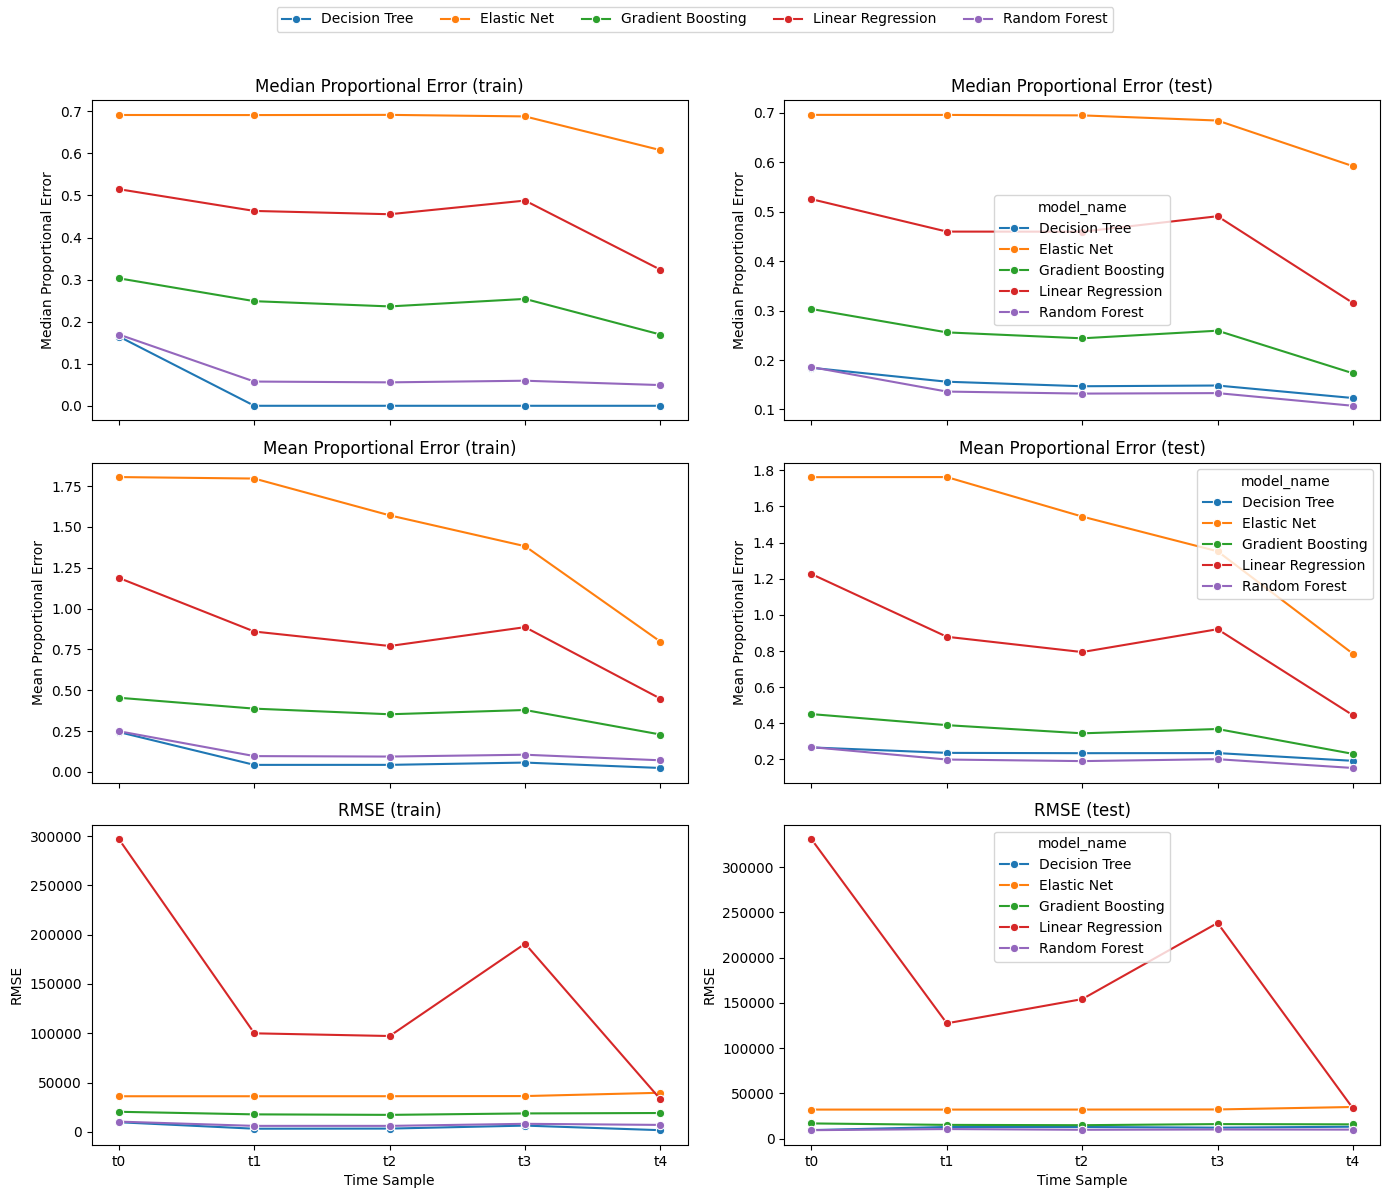

In [14]:
# plot results
lineplots_models_errors_by_time(results_df, "lineplot_err")

Notice the RMSE results begin to go down as time increases but then spike again at t3. This is not surprising, as the datasets that these are being evaluated on change as well. At time t3, it only contains runs where runtime is at least 10 minutes. That way, we are not predicting runtimes of runs that have already finished. Therefore, it would make sense that the RMSE of long runtimes is greater than the RMSE of short runs (like 1 to 5 minutes). This is part of the reason for introducing the proportional error metrics rather than solely relying on RMSE. By looking at those graphs, we can see that the proportional error of the models is going down as is expected.

In general for the proportional error metrics, there is an apparent pattern of linear models learning more as time goes on, however this may not necessarily be the case. Because the time samples remove all past runs that are not as long as the current time sample, these linear models are likely able to generalize better to predict long runs than they are to predict a variety of short to long runs. 

To eliminate the confusion, we can run the same experiment on only the runs that lasted longer than t4 (1 hour). Therefore, all times t0 through t4 will have the same amount of samples. This way, we can see how the accuracy of each model changes over time without any compounding effects.

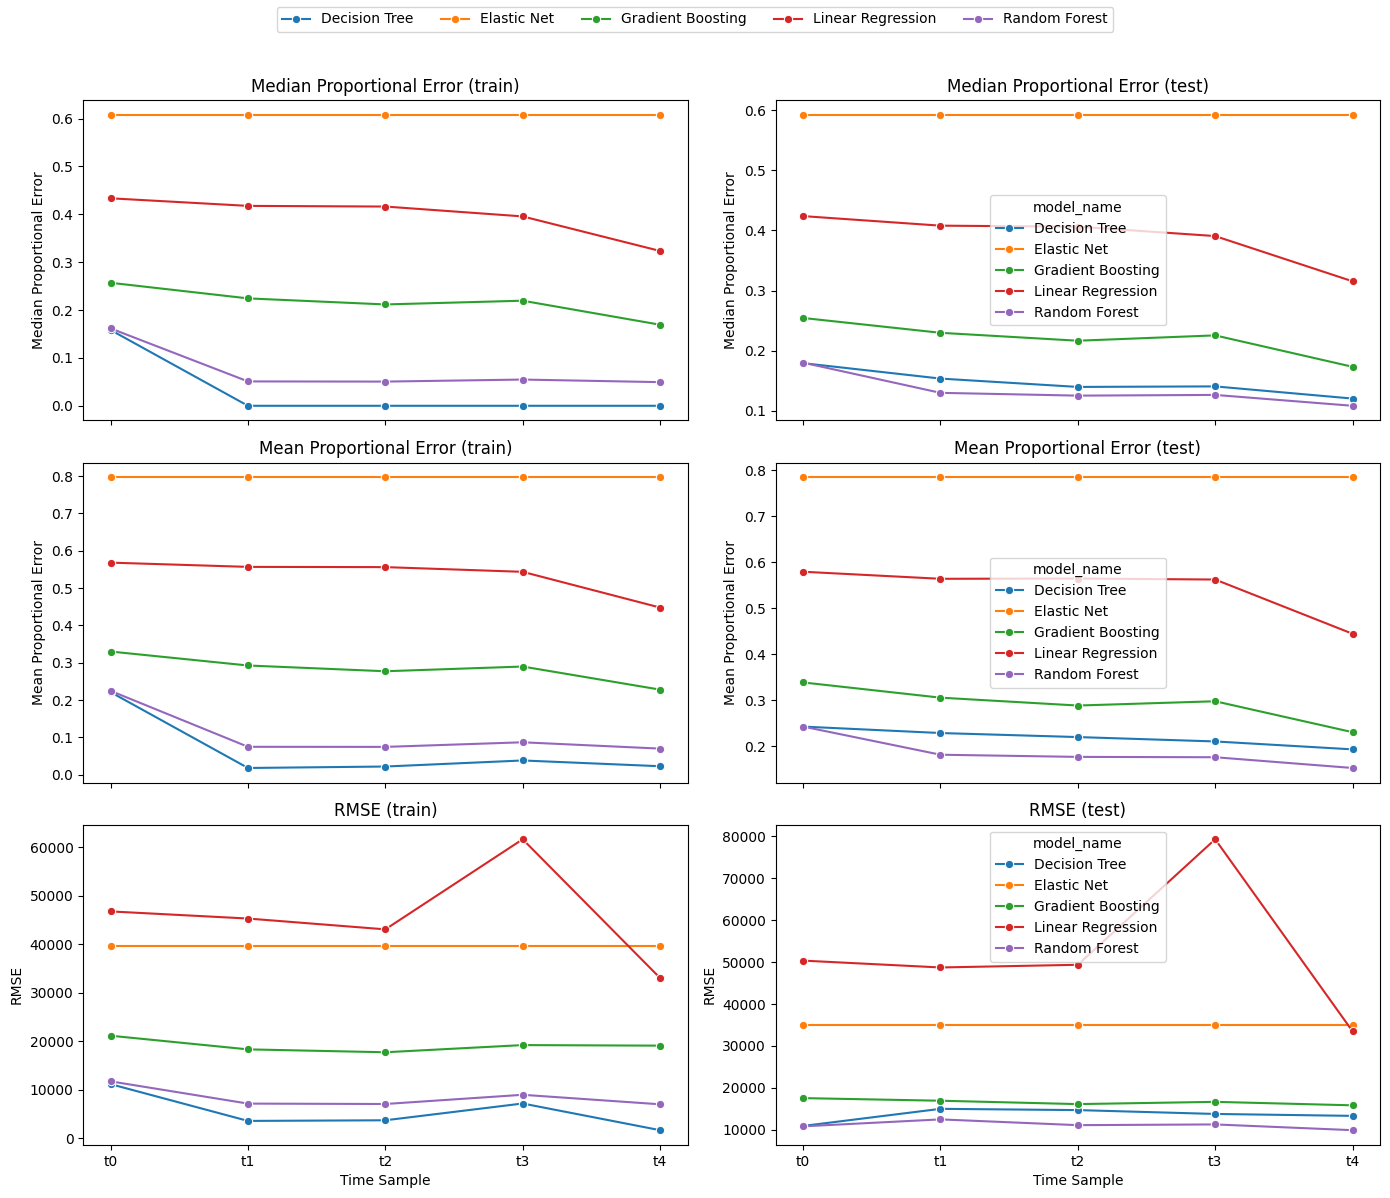

In [15]:
hour = 60*60
df_subset = None
if "log_runtime" in df.columns:
    df_subset = df[df["log_runtime"] > np.log(hour)]
else:
    df_subset = df[df["runtime"] > hour]
df_subset_split = split_df_by_times(df_subset, simple=SIMPLE)
predictions_subset_df = train_and_test_tuned(tuned_models=tuned_models, split_dfs=df_subset_split)
results_subset_df = get_results_df(predictions_subset_df)
lineplots_models_errors_by_time(results_subset_df, "lineplot_err_subset")

Looking at the results of the models on a stable subset of samples over time, it is clear that the Elastic Net was not learning more of the pattern as the time went on. In all error metrics, the Elastic Net seems to be a straight horizontal line, indicating that it has not gained more predictive power at time t4 than time t1. Surprisingly, we do see a downward trend from the linear regression's proportional error metrics as time goes on, indicating that the predictive power of that model did increase over time. Interestingly, the spike for linear regression still occurs at time t3, meaning there may be some relationship that happens around 10 minutes that is harder for the linear regression model to pick up on.

In [16]:
def scatter_prop_errors_vs_runtimes(
        predictions_df: pd.DataFrame,
        dataset: str,
        fig_title: str,
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME):
    """
    Create subplots of prop_error vs runtime scatterplots with rows = models, columns = time samples
    """
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    df = predictions_df[predictions_df["dataset"] == dataset]
    models = df["model_name"].unique()
    times = df["time_sample"].unique()
    n_models = len(models)
    n_times = len(times)
    fig, axes = plt.subplots(
        n_models,
        n_times,
        figsize=(5*n_times, 4*n_models),
        sharey=False
    )
    for i, model_name in enumerate(models):
        for j, t in enumerate(times):
            ax = axes[i, j]
            subset = df[
                (df["model_name"] == model_name) &
                (df["time_sample"] == t)
            ]
            runtimes = subset[runtime_col]
            if log_transformed_runtime:
                runtimes = np.exp(runtimes)
            ax.scatter(
                runtimes,
                subset["prop_error"],
                alpha=0.5
            )
            ax.set_xscale("log")
            if i == 0:
                ax.set_title("Time Sample " + t.title(), fontsize=20)
            if j == 0:
                ax.set_ylabel(f"{model_name}\nProportional Error", fontsize=20)
            if i == n_models - 1:
                ax.set_xlabel("Runtime", fontsize=20)
    fig.suptitle(f"Performance on {dataset.title()} Dataset by Runtime", fontsize=30)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    save_plot(fig_title)
    plt.show()


def boxplot_prop_errors_by_time(predictions_df: pd.DataFrame, fig_title:str):
    """
    Create two (train and test) 2 x N_models/2 subplots where each subplot shows boxplots of 
    proportional errors for all time samples
    """
    datasets = predictions_df["dataset"].unique()
    times = predictions_df["time_sample"].unique()
    models = predictions_df["model_name"].unique()
    n_models = len(models)
    cols = int(np.ceil(n_models / 2))
    for dataset in datasets:
        df = predictions_df[predictions_df["dataset"] == dataset]
        fig, axes = plt.subplots(2, cols, figsize=(6*cols, 10), sharey=False)
        for i, model_name in enumerate(models):
            row = i // cols
            col = i % cols
            ax = axes[row, col]
            model_df = df[df["model_name"] == model_name]
            data = [
                model_df[model_df["time_sample"] == t]["prop_error"]
                for t in times
            ]
            ax.boxplot(data, tick_labels=times)
            ax.set_title(model_name, fontsize=20)
            ax.set_xlabel("Time Sample", fontsize=15)
            if col == 0:
                ax.set_ylabel("Proportional Error", fontsize=15)
        unused_plots = range(n_models, 2*cols)
        for i in unused_plots:
            row = i // cols
            col = i % cols
            axes[row, col].set_visible(False)
        fig.suptitle(f"Performance on {dataset.title()} Dataset", fontsize=30)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        save_plot(fig_title)
        plt.show()

Going back to the entire dataset, let's analyze the proportional errors in more detail using box plots. 

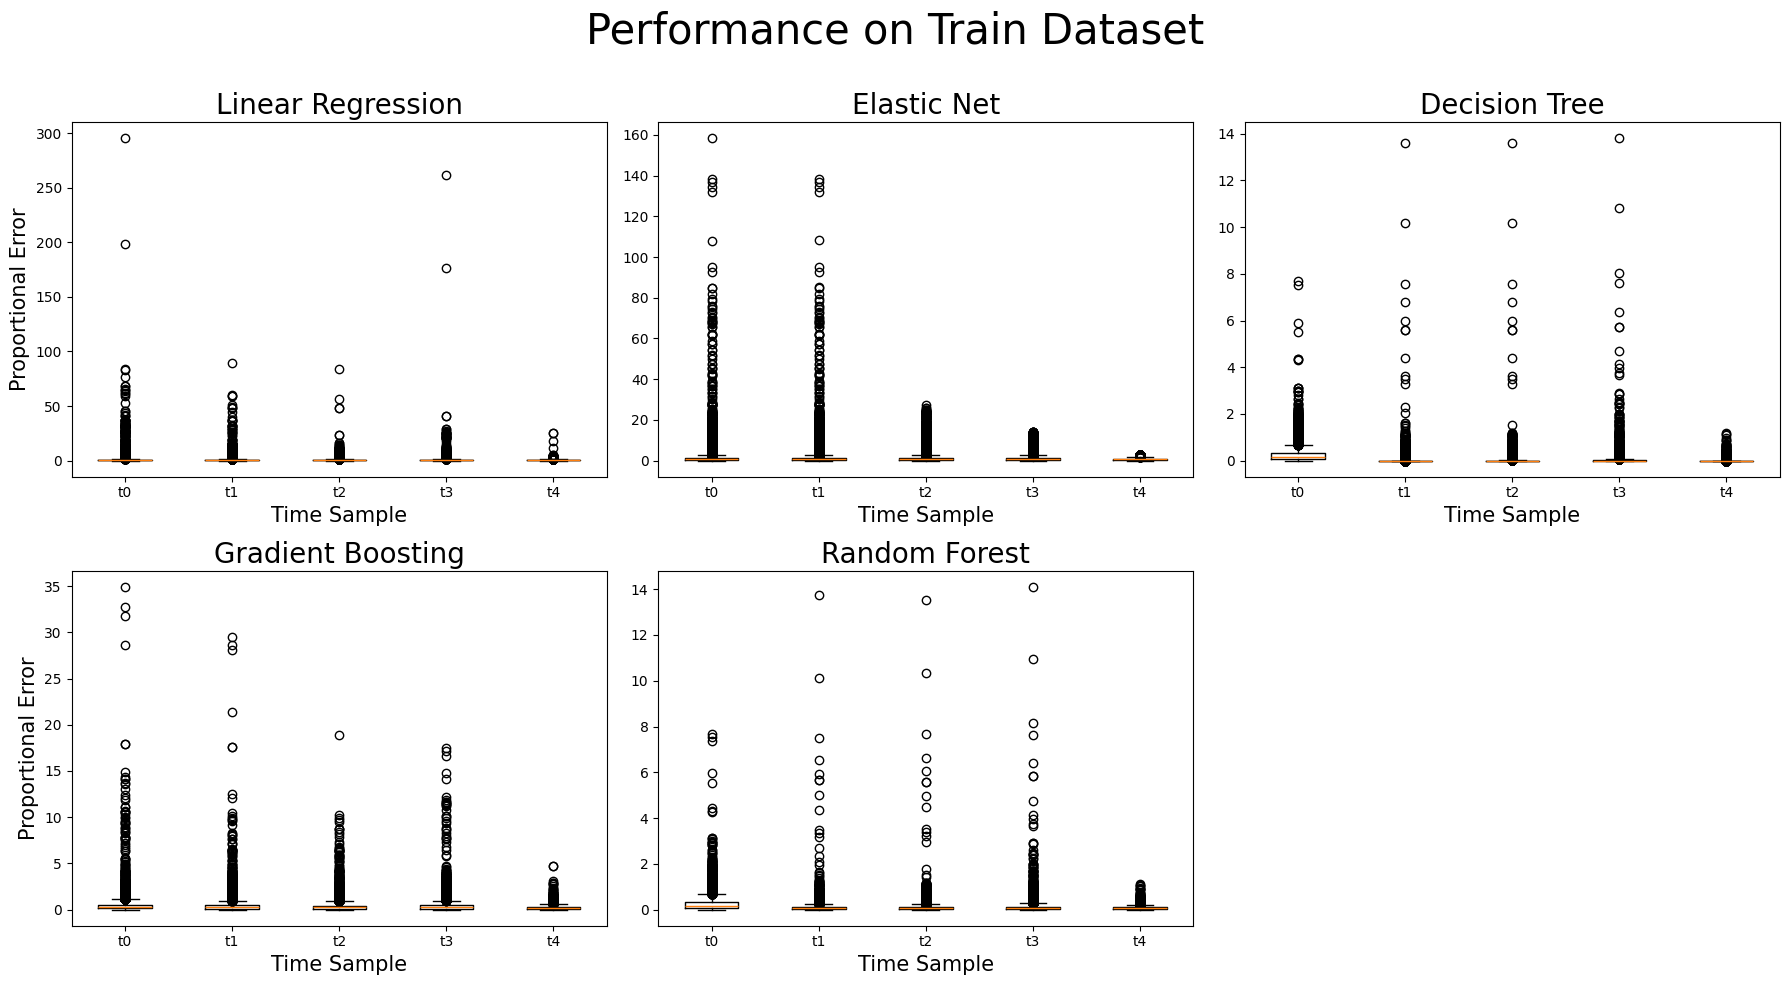

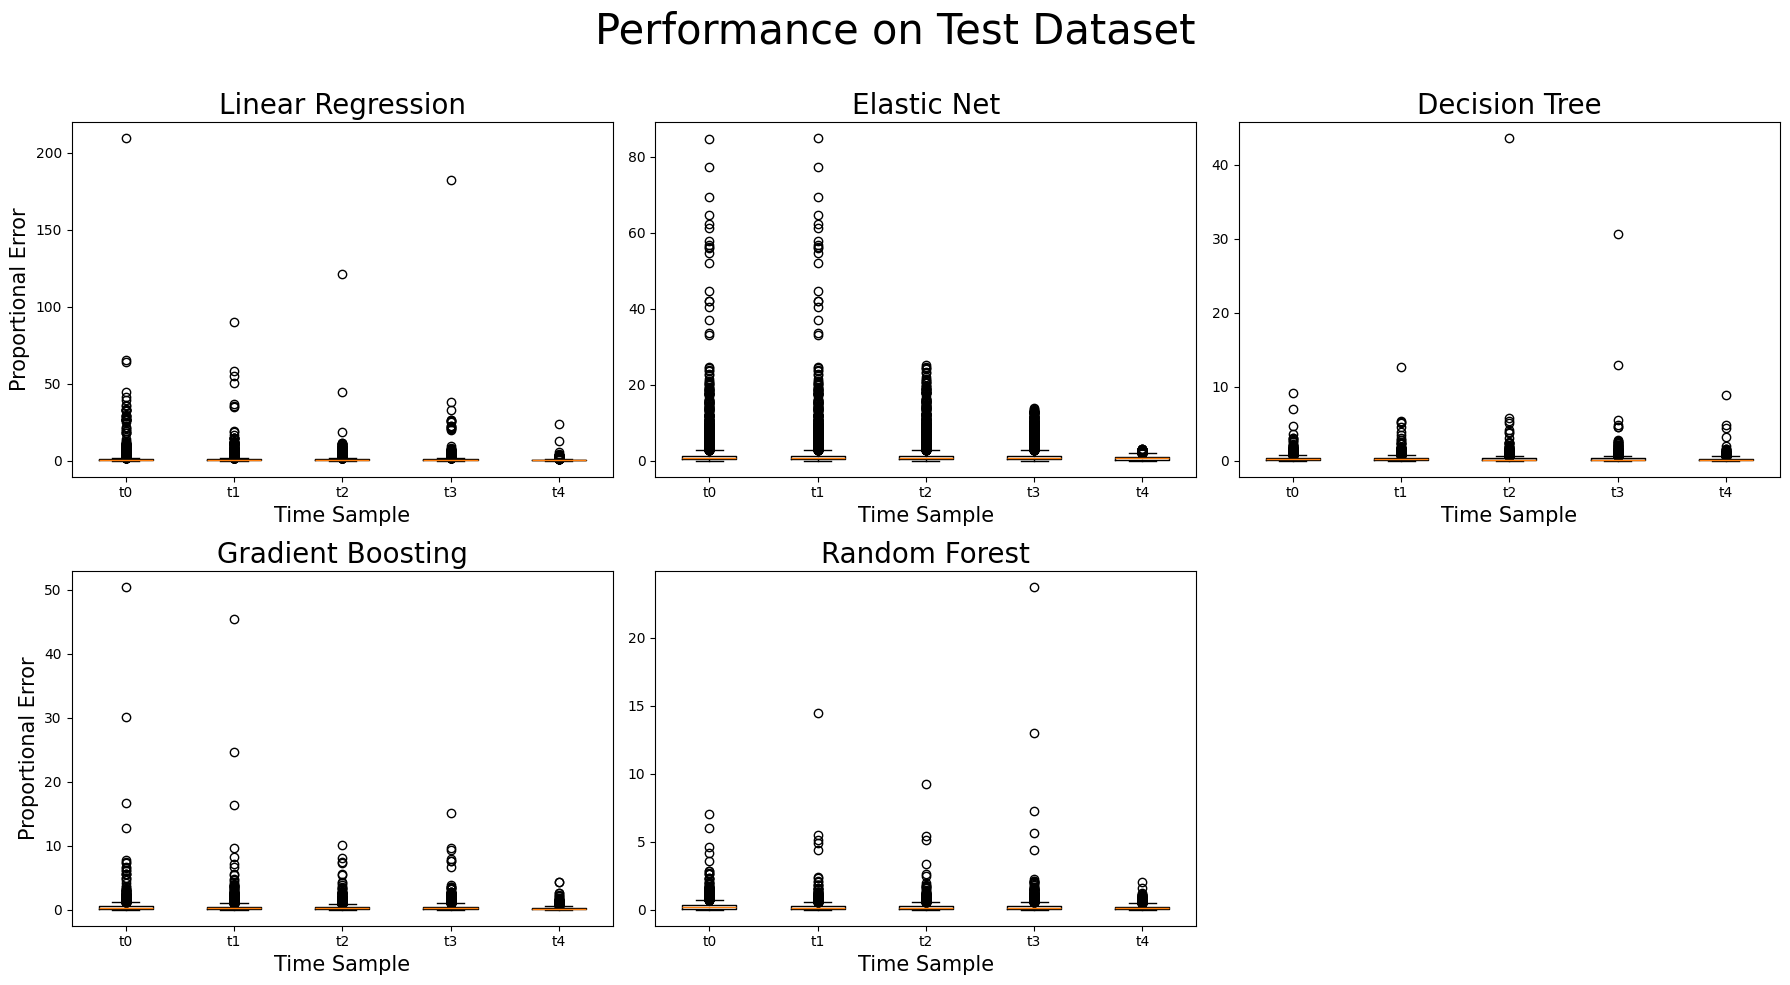

In [17]:
boxplot_prop_errors_by_time(predictions_df, "boxplot_err")

Looking at the box plots of each of these graphs, there appears to be a few outliers where inaccuracy was quite high for each model. Interestingly, these outliers are not necessarily shared across models. In the test dataset, Random Forest has a harder time with outliers in the t3 samples in general, however Elastic Net and Gradient Boosting both have more difficulties with outliers in t0 and t1 samples. This could imply that these outliers are the faults of the models rather than especially difficult to predict samples. Since some models don't have the the same difficulties predicting certain points as others, a lot of the high error points appear to be model-specific.

Overall, the three tree-based models (Decision Tree, Gradient Boosting, and Random Forest) all seem to outperform the linear models both in training and testing. This is not surprising, as a complex fire simulation tool like BurnPro3D is likely to have some non-linearity in relation to its runtime or even log_runtime. Further analyzing the differences between the training and testing results, it seems that Gradient Boosting and Random Forest models perform relatively similarly across training and testing, with the Random Forest doing slightly better than Gradient Boosting. However, the Decision Tree model seems to be overfitting slightly, showing better performance on the training set than the testing set.

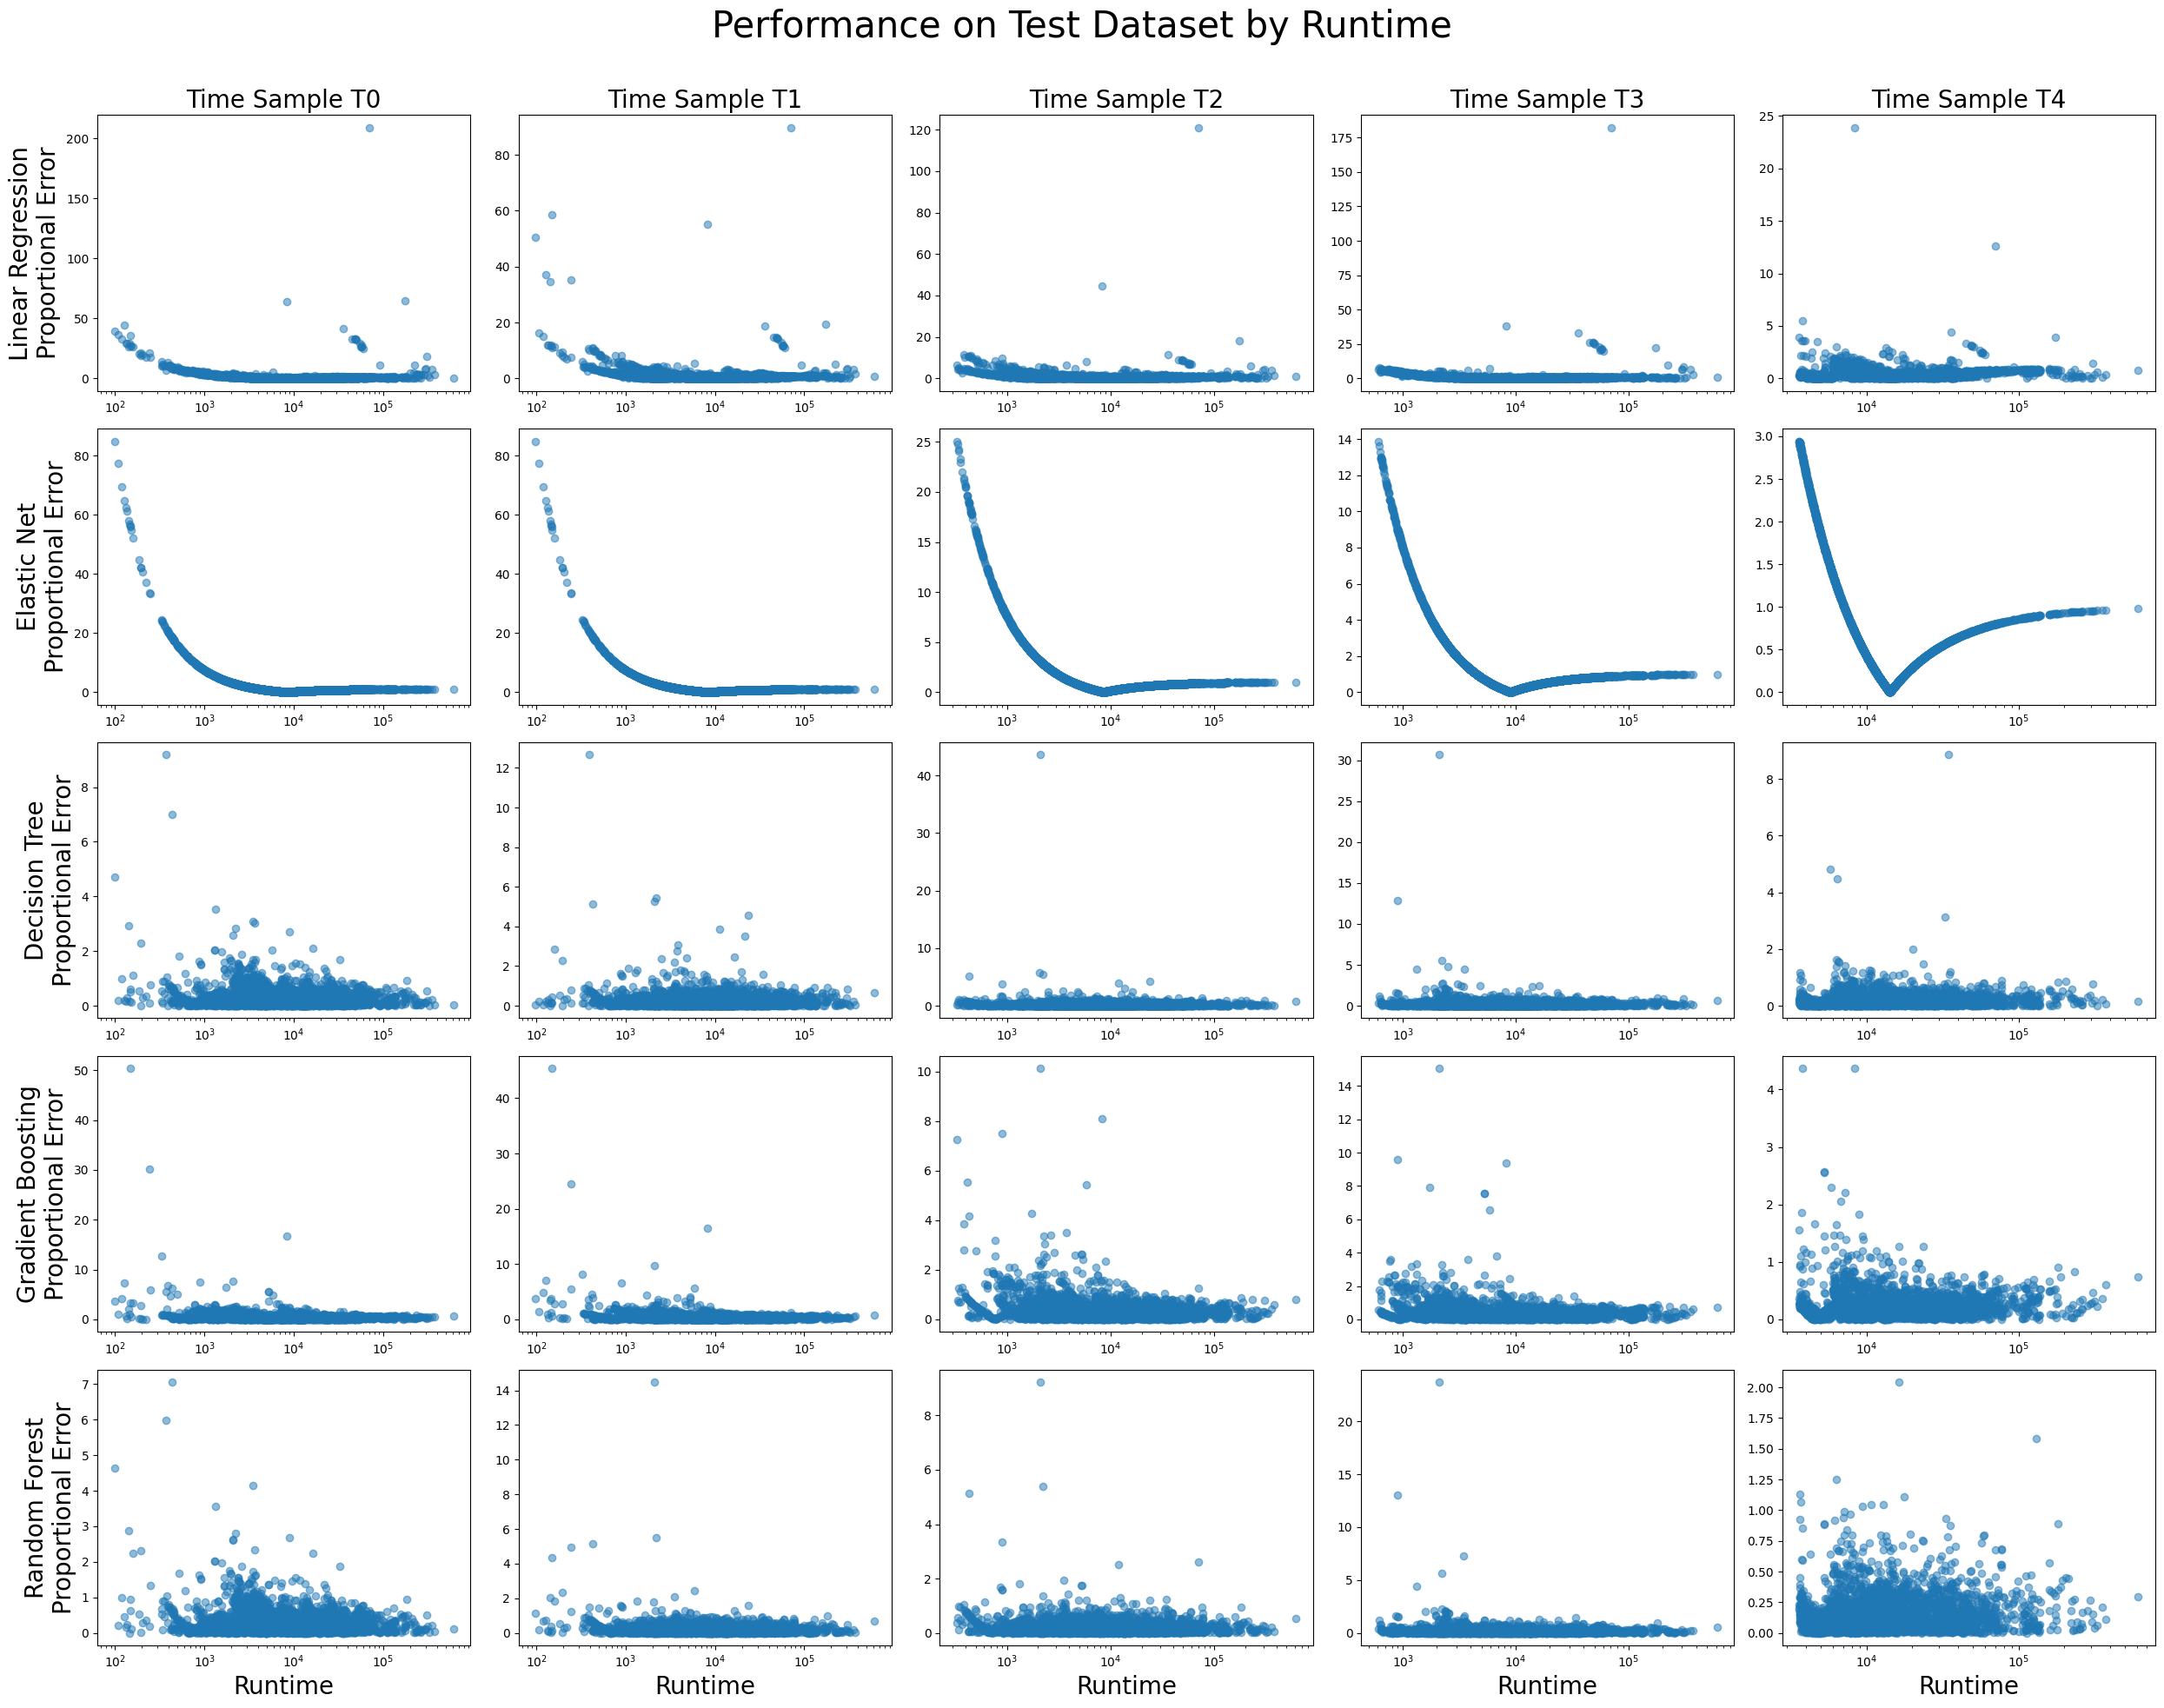

In [18]:
scatter_prop_errors_vs_runtimes(
    predictions_df, dataset="test", fig_title="scatter_err_runtime_test")

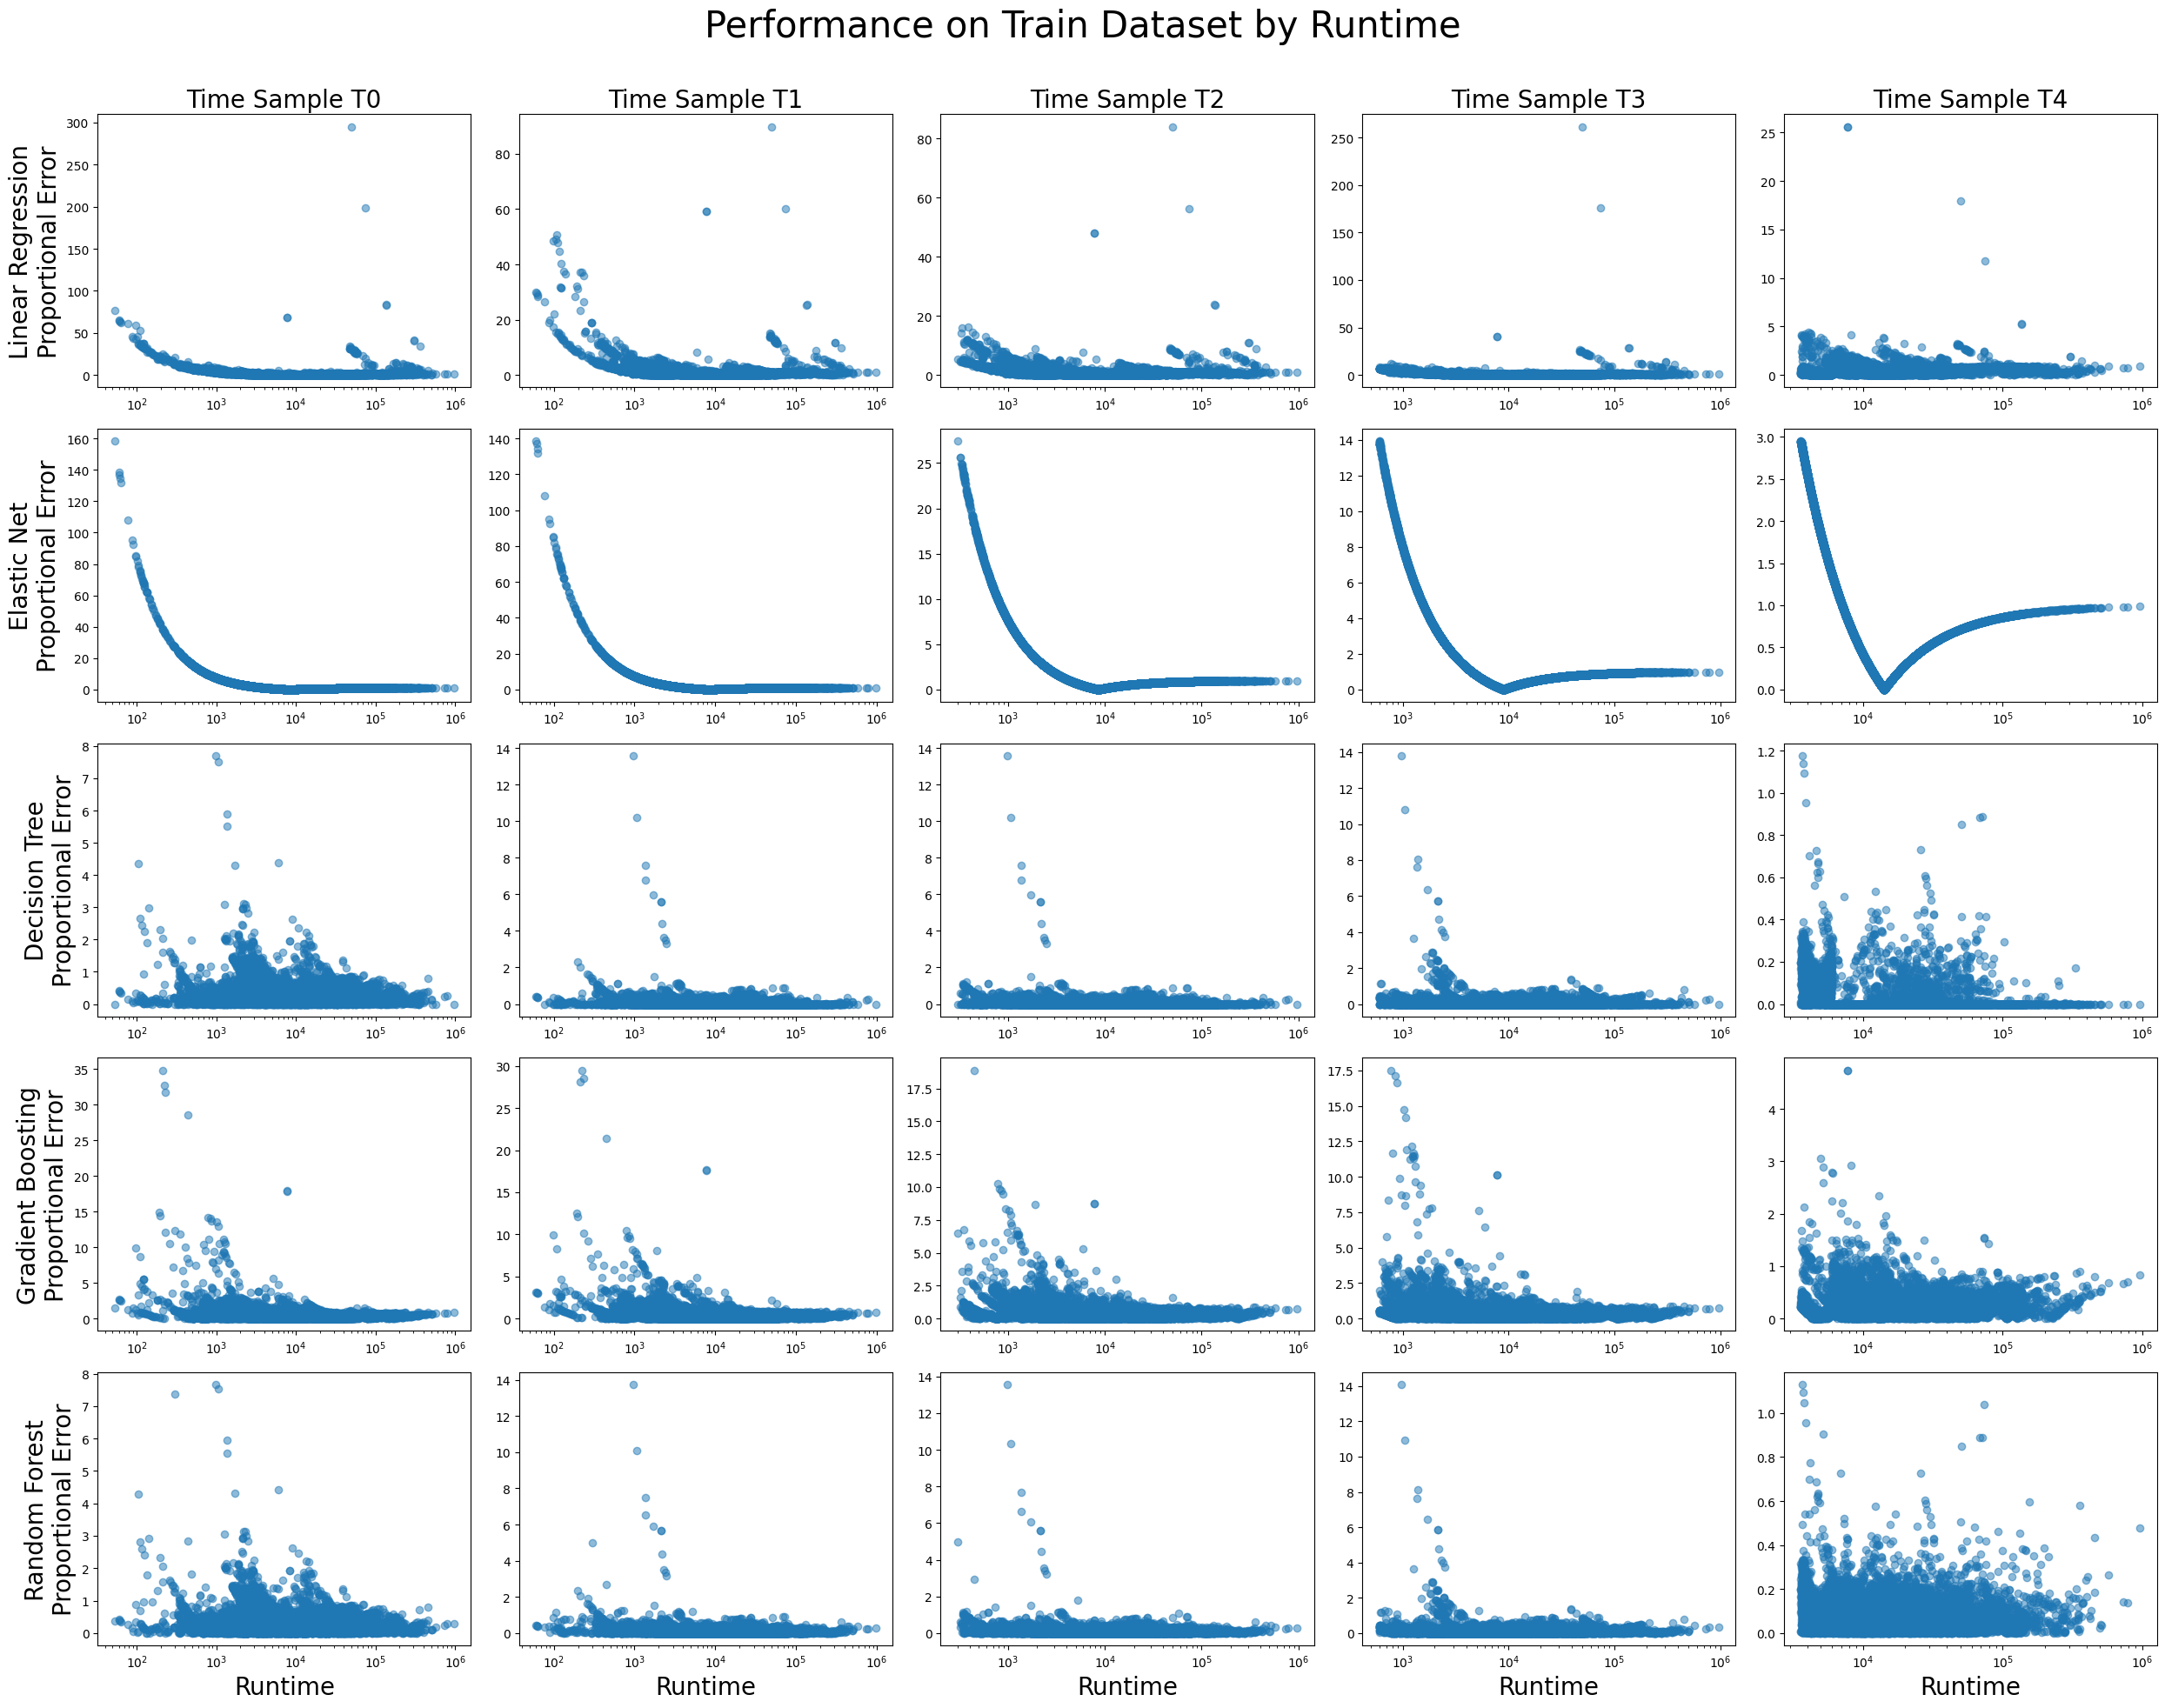

In [19]:
scatter_prop_errors_vs_runtimes(
    predictions_df, dataset="train", fig_title="scatter_err_runtime_train")

There seems to be a very strong signal with the Elastic Net runtimes and proprortional errors. Let's investigate if we can utilize this relationship further by plotting the true runtimes over the predicted runtimes. If this signal is because of some pattern in the Elastic Net, there's a chance we could do some transformation on the output to get a more accurate prediction

In [20]:
def scatter_runtime_vs_pred(
        predictions_df: pd.DataFrame,
        dataset: str,
        fig_title: str,
        log_transformed_runtime:bool = LOG_TRANSFORMED_RUNTIME):
    """
    Create subplots of prop_error vs runtime scatterplots with rows = models, columns = time samples
    """
    runtime_col = "log_runtime" if log_transformed_runtime else "runtime"
    df = predictions_df[predictions_df["dataset"] == dataset]
    model_names = df["model_name"].unique()
    times = df["time_sample"].unique()
    n_times = len(times)
    n_models = len(model_names)
    fig, axes = plt.subplots(
        n_models,
        n_times,
        figsize=(5*n_times, 4*n_models),
        sharey=False
    )
    for i, model_name in enumerate(model_names):
        for j, t in enumerate(times):
            ax = axes[i, j]
            subset = df[
                (df["model_name"] == model_name) &
                (df["time_sample"] == t)
            ]
            runtimes = subset[runtime_col]
            predictions = subset["prediction"]
            if log_transformed_runtime:
                runtimes = np.exp(runtimes)
                predictions = np.exp(predictions)

            ax.scatter(
                predictions,
                runtimes,
                alpha=0.5
            )
            ax.set_xscale("log")
            ax.set_yscale("log")
            if i == 0:
                ax.set_title("Time Sample " + t.title(), fontsize=20)
            if j == 0:
                ax.set_ylabel("Runtime", fontsize=20)
            ax.set_xlabel(f"{model_name} Prediction", fontsize=20)
    fig.suptitle(f"{dataset.title()} Runtimes vs Predictions by model by time", fontsize=30)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    save_plot(fig_title)
    plt.show()

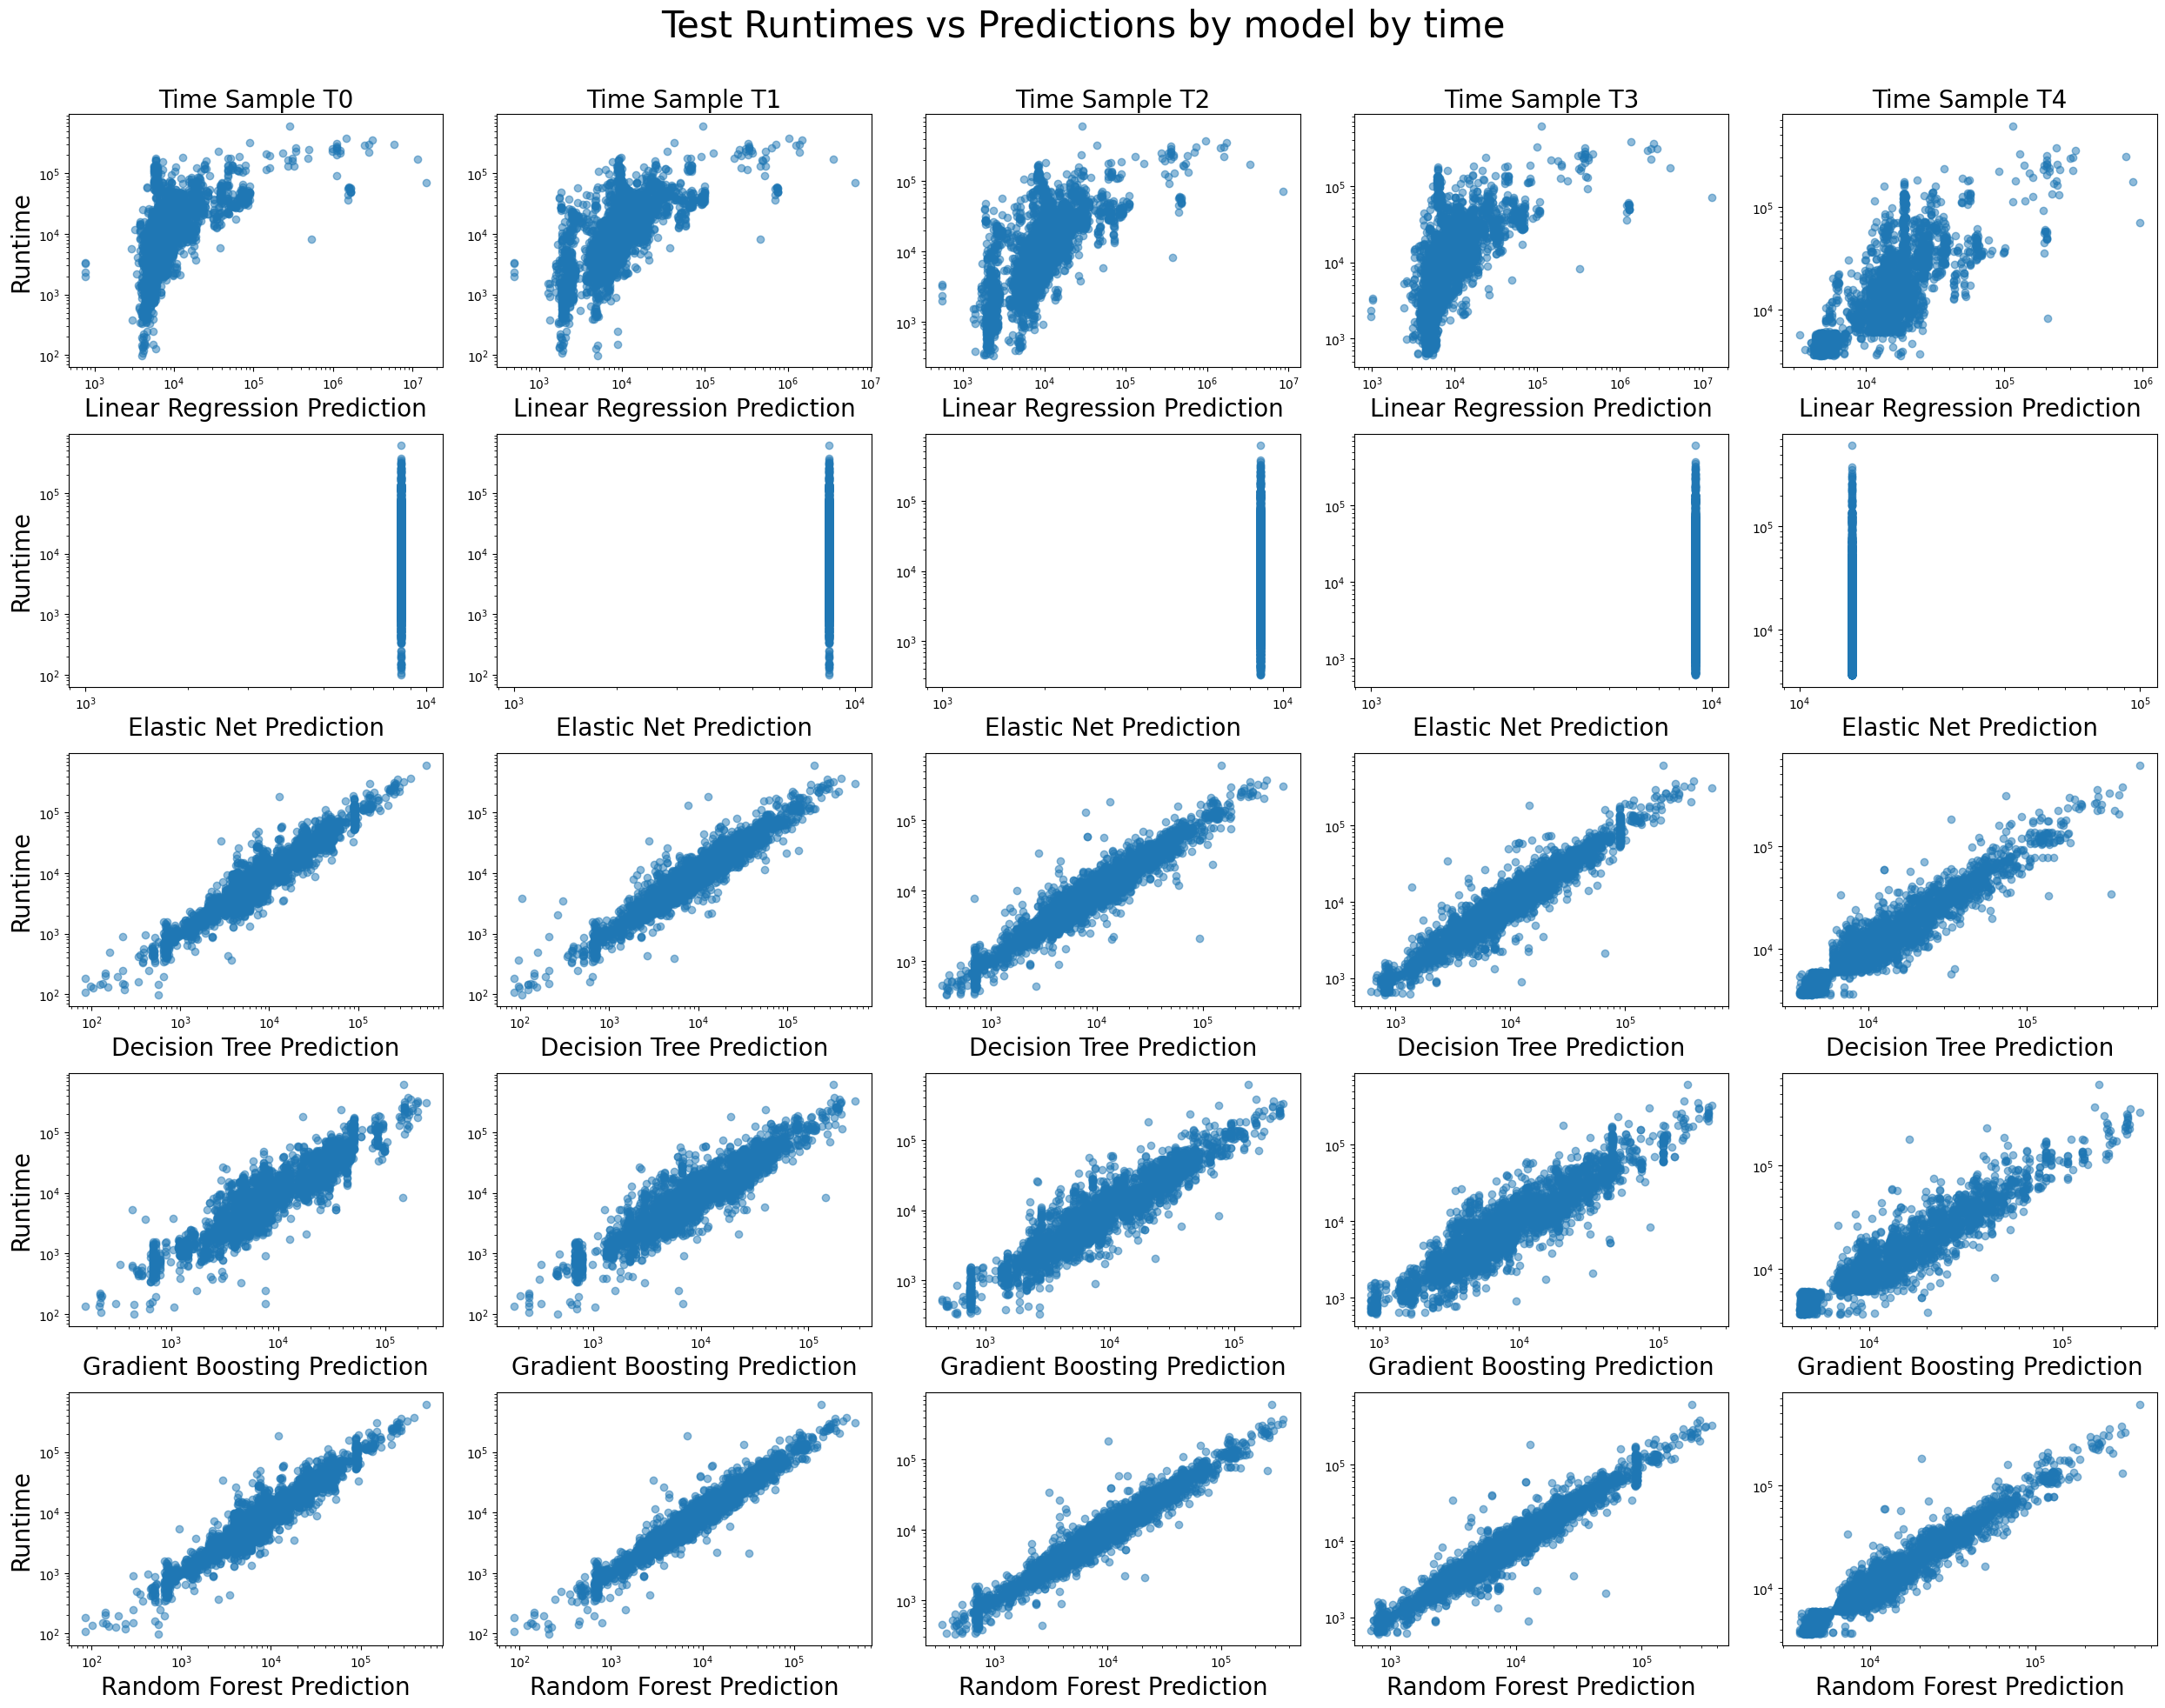

In [21]:
scatter_runtime_vs_pred(predictions_df, dataset="test", fig_title="scatter_runtime_pred_test")

In [22]:
elastic_net_predictions = predictions_df[predictions_df["model_name"] == "Elastic Net"]["prediction"]
print("Unique Elastic Net Predictions:", elastic_net_predictions.unique())
print("Number of Unique Elastic Net Predictions:", elastic_net_predictions.nunique())

Unique Elastic Net Predictions: [9.03891877 9.03923079 9.05738372 9.10252593 9.56256881]
Number of Unique Elastic Net Predictions: 5


Looking at the relationship between the Elastic Net predictions and true runtime, it appears that the signal was more of a pattern of proportional error rather than some predictive capabilities of the Elastic Net. The Elastic Net has essentially collapsed to always predict one of a select few values, in this case, one of 5 values that were all very close in magnitude.

Essentially, the Elastic Net returned a constant c, and so the signal we saw being graphed earlier was |runtime - c| / runtime, which decreases as runtime approaches c, then levels off towards 1 as runtime becomes much greater than c. This is exactly the shape of the graph we saw. Thus, we cannot use the outputs of the Elastic Net model for any useful predictions.

Based on the outputs of the prediction plots, it looks like most of the models are doing well at predicting runtimes overall, even when the runtimes become extreme. Because of this, it does not seem like outlier removal would help in this case, as the extreme runtime values are not causing the model to be any less accurate. 